## Variance F test

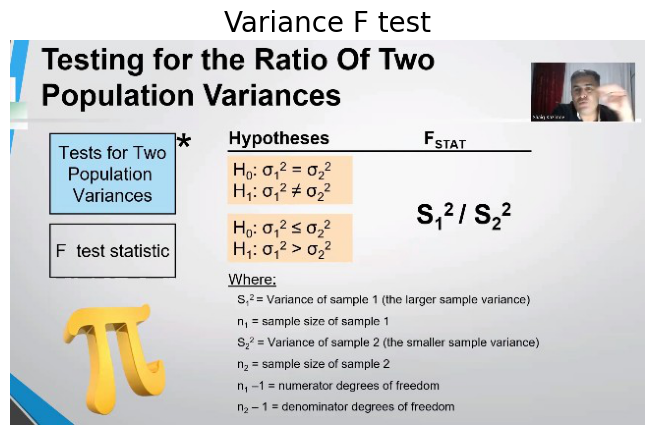

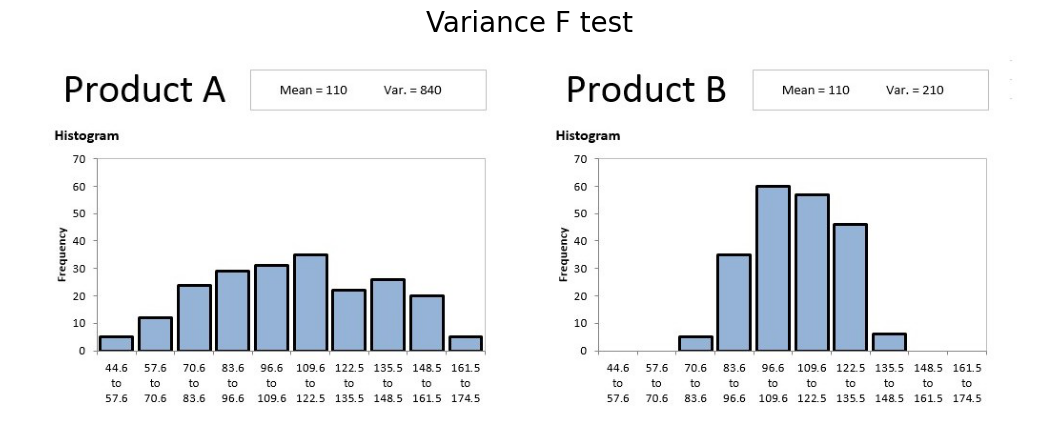

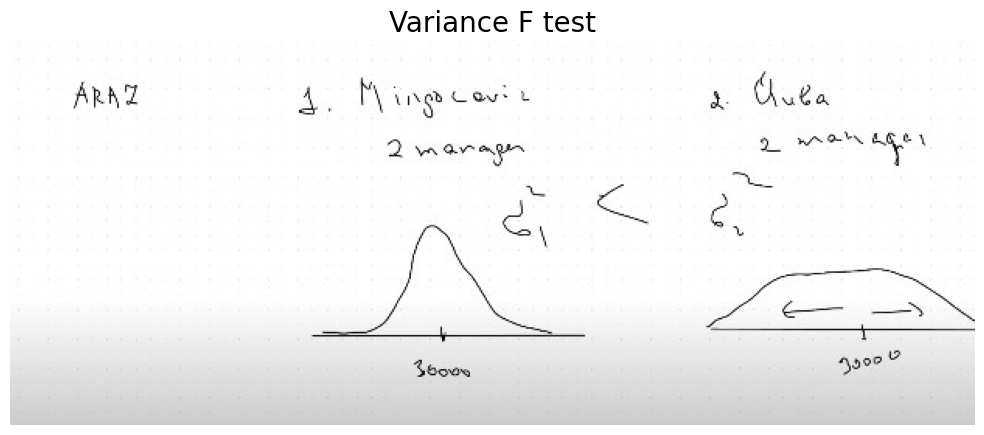

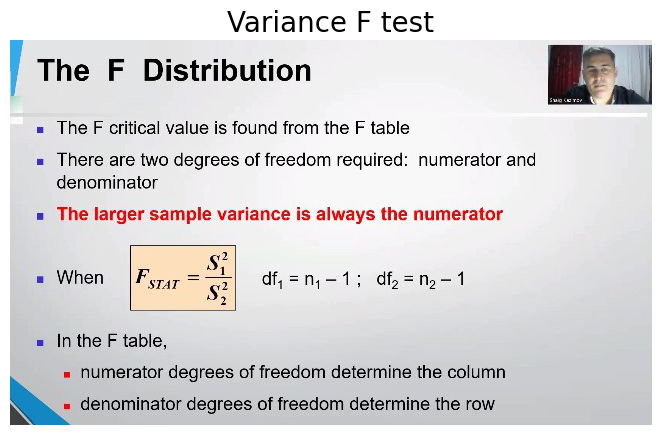

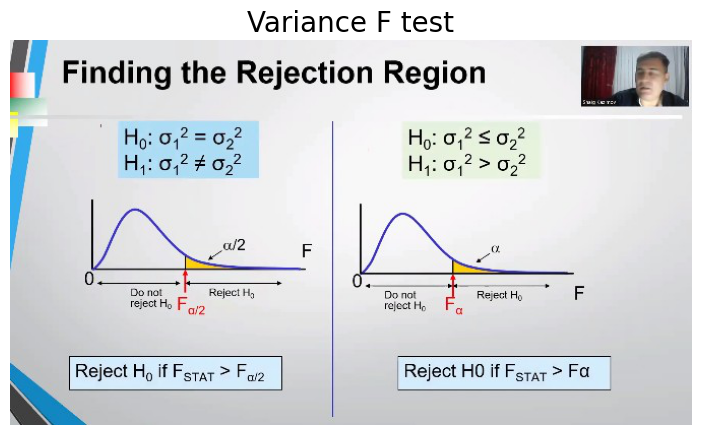

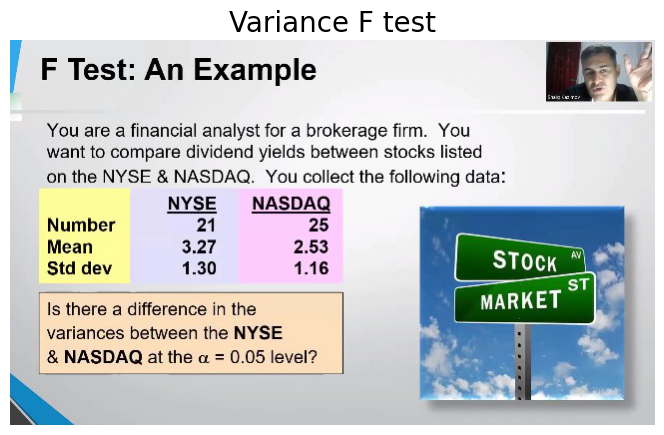

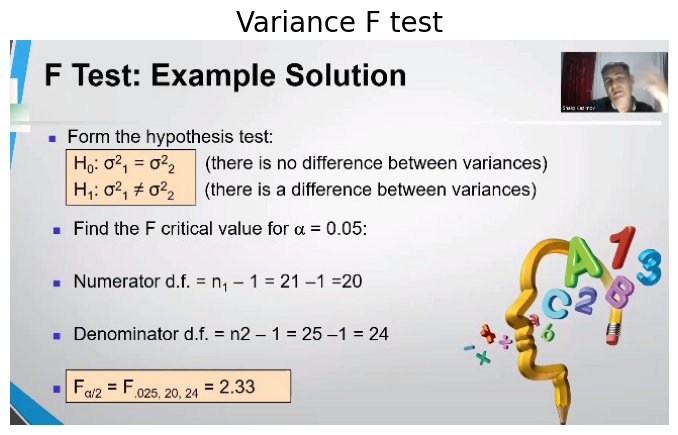

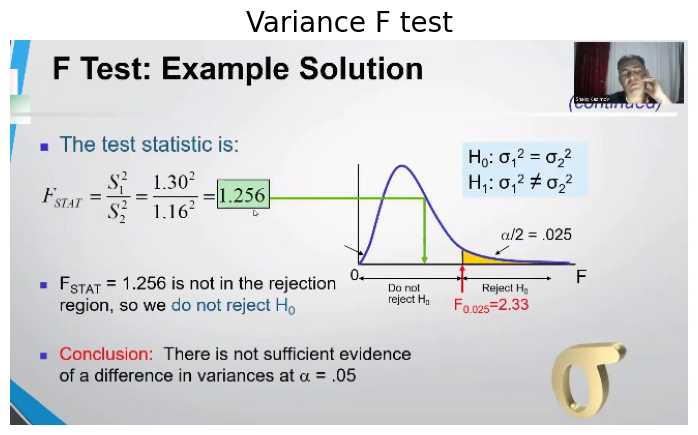

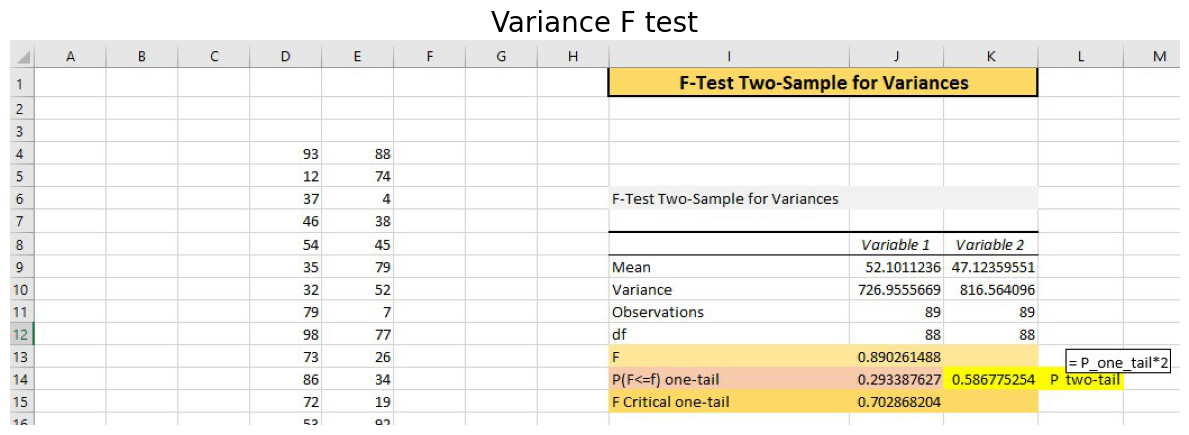

In [44]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Excel\Handex Excel\Statistics\Season_2\Telim_11\Pictures\Distribution_4_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 10):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for image in image_list:
    plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü
    plt.title("Variance F test", size=20)
    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

## Variance F test Analys in İnvesting

https://www.investing.com/equities

In [12]:
import numpy as np
import pandas as pd
import yfinance as yf

In [13]:
mcrft = pd.DataFrame(yf.download(['MSFT', "AAPL"], period='1y', interval='1d')['Close'])
mcrft

C:\Users\dell\AppData\Local\Temp\ipykernel_2040\3282854933.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  mcrft = pd.DataFrame(yf.download(['MSFT', "AAPL"], period='1y', interval='1d')['Close'])
[*********************100%***********************]  2 of 2 completed


Ticker,AAPL,MSFT
Date,,
2024-08-21,225.351212,421.671570
2024-08-22,223.489868,413.131531
2024-08-23,225.789185,414.364319
2024-08-26,226.127594,411.083496
2024-08-27,226.973663,411.431458
...,...,...
2025-08-14,232.779999,522.479980
2025-08-15,231.589996,520.169983
2025-08-18,230.889999,517.099976


In [14]:
mcrft['Return_M'] = mcrft['MSFT'].pct_change()*100
mcrft['Return_A'] = mcrft['AAPL'].pct_change()*100

In [15]:
mcrft.dropna()

Ticker,AAPL,MSFT,Return_M,Return_A
Date,,,,
2024-08-22,223.489868,413.131531,-2.025282,-0.825974
2024-08-23,225.789185,414.364319,0.298401,1.028824
2024-08-26,226.127594,411.083496,-0.791773,0.149878
2024-08-27,226.973663,411.431458,0.084645,0.374156
2024-08-28,225.440811,408.210358,-0.782901,-0.675344
...,...,...,...,...
2025-08-14,232.779999,522.479980,0.364970,-0.235719
2025-08-15,231.589996,520.169983,-0.442122,-0.511213
2025-08-18,230.889999,517.099976,-0.590193,-0.302257


In [20]:
print(f"MSFT Mean: {np.mean(mcrft['Return_M'])}")
print(f"MSFT Stdev: {np.std(mcrft['Return_M'])}")
print(f"MSFT Var: {np.var(mcrft['Return_M'])}\n")
print(f"AAPL Mean: {np.mean(mcrft['Return_A'])}")
print(f"AAPL Stdev: {np.std(mcrft['Return_A'])}")
print(f"AAPL Var: {np.var(mcrft['Return_A'])}")

MSFT Mean: 0.08526439830559907
MSFT Stdev: 1.5723367989587058
MSFT Var: 2.4722430093597096

AAPL Mean: 0.021423485145561125
AAPL Stdev: 2.024862744065513
AAPL Var: 4.10006913230452


In [37]:
F_stat = np.var(mcrft['Return_A']) / np.var(mcrft['Return_M'])
print(f"F stat = {F_stat:.5f}")

F stat = 1.65844


In [38]:
alpha = 0.05
df1 = len(mcrft)-1
df2 = len(mcrft)-1
print(f"alpha = {alpha}\ndf1 = {df1}\ndf2 = {df2}")

alpha = 0.05
df1 = 249
df2 = 249


In [39]:
# Kritik F dəyəri
f_alpha = stats.f.ppf(1 - alpha, df1, df2)

print("F alfa (0.05) =", f_alpha)

F alfa (0.05) = 1.2322913766367205


In [40]:
import numpy as np
from scipy import stats

p_value = 2 * min(stats.f.cdf(F_stat, df1, df2), 1 - stats.f.cdf(F_stat, df1, df2))
print(f"p value = {p_value:.5f}")

p value = 0.00007
